In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/zomato_reviews.csv")
df.head()

,review_id,restaurant_name,cuisine_type,city,rating,delivery_time_mins,order_value_inr,review_text,sentiment_label
0,ZR-0001,Wow Momo,Italian,Chennai,4,29,900.0,"Delivery executive was very courteous, food wa...",Positive
1,ZR-0002,Fasoos,Continental,Bangalore,4,89,594.0,"Paneer butter masala was outstanding, naan was...",Positive
2,ZR-0003,Mainland China,North Indian,Hyderabad,3,38,809.0,"Food was okay, nothing special but edible and ...",Neutral
3,ZR-0004,Barbeque Nation,Italian,Kolkata,1,44,318.0,"Quantity was extremely less for the price, fel...",Negative
4,ZR-0005,Haldirams,Chinese,Mumbai,2,35,772.0,"App showed 30 mins but took 2 hours, no update...",Negative


In [3]:
df.isna().sum()

,0
review_id,0
restaurant_name,0
cuisine_type,0
city,0
rating,0
delivery_time_mins,0
order_value_inr,0
review_text,0
sentiment_label,0


In [4]:
df["rating"].value_counts()

,count
rating,
5,702
4,558
3,303
1,250
2,187


In [5]:
df.groupby("city")["rating"].mean().sort_values(ascending=False)

,rating
city,
Delhi,3.780083
Pune,3.718254
Jaipur,3.700375
Bangalore,3.653846
Kolkata,3.598425
Hyderabad,3.570881
Mumbai,3.566210
Chennai,3.504065


In [6]:
df.groupby("city")["delivery_time_mins"].mean().sort_values(ascending=False)

,delivery_time_mins
city,
Kolkata,55.641732
Pune,55.412698
Chennai,54.520325
Jaipur,54.426966
Delhi,54.186722
Bangalore,53.723077
Hyderabad,53.107280
Mumbai,52.333333


In [7]:
df.groupby("city")["order_value_inr"].mean().sort_values(ascending=False)

,order_value_inr
city,
Bangalore,651.357692
Delhi,647.701245
Kolkata,642.988189
Jaipur,640.000000
Hyderabad,632.988506
Chennai,629.861789
Mumbai,626.652968
Pune,622.380952


In [8]:
df.groupby("cuisine_type")["rating"].mean().sort_values(ascending=False)

,rating
cuisine_type,
Italian,3.810924
Biryani,3.658537
North Indian,3.653846
Mughlai,3.645756
Fast Food,3.625514
South Indian,3.614173
Chinese,3.583658
Continental,3.521401


In [9]:
df.groupby('sentiment_label')['order_value_inr'].mean()

,order_value_inr
sentiment_label,
Negative,622.836735
Neutral,636.916168
Positive,642.024490


In [10]:
from nltk.corpus import stopwords

In [11]:
from nltk.stem import WordNetLemmatizer
import nltk

In [12]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [13]:
lm=WordNetLemmatizer()
sw=stopwords.words("english")

In [14]:
df.head()

,review_id,restaurant_name,cuisine_type,city,rating,delivery_time_mins,order_value_inr,review_text,sentiment_label
0,ZR-0001,Wow Momo,Italian,Chennai,4,29,900.0,"Delivery executive was very courteous, food wa...",Positive
1,ZR-0002,Fasoos,Continental,Bangalore,4,89,594.0,"Paneer butter masala was outstanding, naan was...",Positive
2,ZR-0003,Mainland China,North Indian,Hyderabad,3,38,809.0,"Food was okay, nothing special but edible and ...",Neutral
3,ZR-0004,Barbeque Nation,Italian,Kolkata,1,44,318.0,"Quantity was extremely less for the price, fel...",Negative
4,ZR-0005,Haldirams,Chinese,Mumbai,2,35,772.0,"App showed 30 mins but took 2 hours, no update...",Negative


In [15]:
df["clean_text"]=df["review_text"].str.lower()  # ensuring the words are in lowercase

In [ ]:
df.head()

,review_id,restaurant_name,cuisine_type,city,rating,delivery_time_mins,order_value_inr,review_text,sentiment_label,clean_text
0,ZR-0001,Wow Momo,Italian,Chennai,4,29,900.0,"Delivery executive was very courteous, food wa...",Positive,"delivery executive was very courteous, food wa..."
1,ZR-0002,Fasoos,Continental,Bangalore,4,89,594.0,"Paneer butter masala was outstanding, naan was...",Positive,"paneer butter masala was outstanding, naan was..."
2,ZR-0003,Mainland China,North Indian,Hyderabad,3,38,809.0,"Food was okay, nothing special but edible and ...",Neutral,"food was okay, nothing special but edible and ..."
3,ZR-0004,Barbeque Nation,Italian,Kolkata,1,44,318.0,"Quantity was extremely less for the price, fel...",Negative,"quantity was extremely less for the price, fel..."
4,ZR-0005,Haldirams,Chinese,Mumbai,2,35,772.0,"App showed 30 mins but took 2 hours, no update...",Negative,"app showed 30 mins but took 2 hours, no update..."


In [16]:
import re

In [17]:
df['clean_text']=df['clean_text'].apply(lambda x:re.sub(r'[^\w\s]',"",x))

In [18]:
df['clean_text']=df['clean_text'].apply(lambda x:re.sub(r"\d+","",x))

In [19]:
df['clean_text']=df['clean_text'].apply(lambda x:" ".join([word for word in x.split() if word not in sw]))

In [20]:
df["clean_text"]=df['clean_text'].apply(lambda x:" ".join([lm.lemmatize(word) for word in x.split()]))

In [21]:
df[['clean_text',"review_text"]].head()

,clean_text,review_text
0,delivery executive courteous food well packed ...,"Delivery executive was very courteous, food wa..."
1,paneer butter masala outstanding naan soft fresh,"Paneer butter masala was outstanding, naan was..."
2,food okay nothing special edible delivery time,"Food was okay, nothing special but edible and ..."
3,quantity extremely less price felt cheated com...,"Quantity was extremely less for the price, fel..."
4,app showed min took hour update apology given,"App showed 30 mins but took 2 hours, no update..."


In [22]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


In [23]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vs = SentimentIntensityAnalyzer()

In [27]:
df['vs_compound']=df['review_text'].apply(lambda x:vs.polarity_scores(x)["compound"])

In [29]:
df["vs_sentiment"]=df["vs_compound"].apply(lambda x: "positive" if x>=0.5 else("negative" if x<= -0.05 else "neutral"))

In [ ]:
df[['review_text', 'vs_compound', 'vs_sentiment', 'sentiment_label']].head(10)

,review_text,vs_compound,vs_sentiment,sentiment_label
0,"Delivery executive was very courteous, food wa...",0.6901,positive,Positive
1,"Paneer butter masala was outstanding, naan was...",0.7430,positive,Positive
2,"Food was okay, nothing special but edible and ...",-0.0462,neutral,Neutral
3,"Quantity was extremely less for the price, fel...",-0.5106,negative,Negative
4,"App showed 30 mins but took 2 hours, no update...",-0.4628,negative,Negative
5,"Fried rice was amazing, portions were huge and...",0.8126,positive,Positive
6,"Arrived hot and fresh, taste was amazing, will...",0.8316,positive,Positive
7,"Pizza was crispy and loaded with toppings, del...",0.0000,neutral,Positive
8,"Arrived hot and fresh, taste was amazing, will...",0.8316,positive,Positive
9,"Best biryani I have ever ordered, rice was per...",0.9136,positive,Positive


In [30]:
accuracy = (df['vs_sentiment'] == df['sentiment_label'].str.lower()).mean() * 100
print(f"VADER Accuracy: {accuracy:.2f}%")

VADER Accuracy: 67.00%


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tfidf=TfidfVectorizer(max_features=3000,ngram_range=(1,2),min_df=2)
X=tfidf.fit_transform(df['clean_text'])
print(X.shape)

(2000, 682)


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train,x_test,y_train,y_test=train_test_split(X,df['sentiment_label'],test_size=0.2,random_state=42,stratify=df['sentiment_label'])

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

In [36]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)
print(accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred))

96.25
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.95        88
     Neutral       0.98      0.87      0.92        67
    Positive       0.96      0.99      0.98       245

    accuracy                           0.96       400
   macro avg       0.96      0.94      0.95       400
weighted avg       0.96      0.96      0.96       400



In [ ]:
from google.colab import files

df.to_csv('zomato_final.csv', index=False)
files.download('zomato_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
aspects = {
    'Food Quality': ['food', 'taste', 'fresh', 'cold',
                     'stale', 'hot', 'tasty', 'crispy',
                     'delicious', 'bland'],

    'Delivery Speed': ['delivery', 'late', 'delayed',
                       'fast', 'quick', 'slow', 'time'],

    'Packaging': ['packaging', 'packed', 'spilled',
                  'sealed', 'bag', 'box'],

    'Price/Value': ['price', 'expensive', 'cheap',
                    'worth', 'value', 'overpriced'],

    'Quantity': ['quantity', 'portion', 'less',
                 'enough', 'small', 'large'],

    'Customer Service': ['service', 'staff', 'rude',
                         'helpful', 'courteous']
}

In [ ]:
df.head()

,review_id,restaurant_name,cuisine_type,city,rating,delivery_time_mins,order_value_inr,review_text,sentiment_label,clean_text,vs_compund,vs_sentiment,vs_compound
0,ZR-0001,Wow Momo,Italian,Chennai,4,29,900.0,"Delivery executive was very courteous, food wa...",Positive,delivery executive courteous food well packed ...,0.6901,positive,0.6901
1,ZR-0002,Fasoos,Continental,Bangalore,4,89,594.0,"Paneer butter masala was outstanding, naan was...",Positive,paneer butter masala outstanding naan soft fresh,0.7430,positive,0.7430
2,ZR-0003,Mainland China,North Indian,Hyderabad,3,38,809.0,"Food was okay, nothing special but edible and ...",Neutral,food okay nothing special edible delivery time,-0.0462,neutral,-0.0462
3,ZR-0004,Barbeque Nation,Italian,Kolkata,1,44,318.0,"Quantity was extremely less for the price, fel...",Negative,quantity extremely less price felt cheated com...,-0.5106,negative,-0.5106
4,ZR-0005,Haldirams,Chinese,Mumbai,2,35,772.0,"App showed 30 mins but took 2 hours, no update...",Negative,app showed min took hour update apology given,-0.4628,negative,-0.4628


In [39]:
def get_aspects(text):
    found = []
    for aspect, keywords in aspects.items():
        for word in keywords:
            if word in text:
                found.append(aspect)
                break
    return found if found else ['General']

df['aspects'] = df['clean_text'].apply(get_aspects)
df[['review_text', 'aspects']].head(10)

,review_text,aspects
0,"Delivery executive was very courteous, food wa...","[Food Quality, Delivery Speed, Packaging, Cust..."
1,"Paneer butter masala was outstanding, naan was...",[Food Quality]
2,"Food was okay, nothing special but edible and ...","[Food Quality, Delivery Speed]"
3,"Quantity was extremely less for the price, fel...","[Price/Value, Quantity]"
4,"App showed 30 mins but took 2 hours, no update...",[General]
5,"Fried rice was amazing, portions were huge and...","[Price/Value, Quantity]"
6,"Arrived hot and fresh, taste was amazing, will...",[Food Quality]
7,"Pizza was crispy and loaded with toppings, del...","[Food Quality, Delivery Speed]"
8,"Arrived hot and fresh, taste was amazing, will...",[Food Quality]
9,"Best biryani I have ever ordered, rice was per...",[Quantity]


In [40]:
aspect_sentiment = {}

for aspect in aspects.keys():
    aspect_df = df[df['aspects'].apply(lambda x: aspect in x)]
    sentiment_counts = aspect_df['sentiment_label'].value_counts()
    aspect_sentiment[aspect] = sentiment_counts

aspect_df_result = pd.DataFrame(aspect_sentiment).T.fillna(0)
print(aspect_df_result)

sentiment_label   Negative  Neutral  Positive
Food Quality           210      219       767
Delivery Speed          66      119       285
Packaging               61       41       137
Price/Value             20       57        97
Quantity                50       38       188
Customer Service        14        3        48


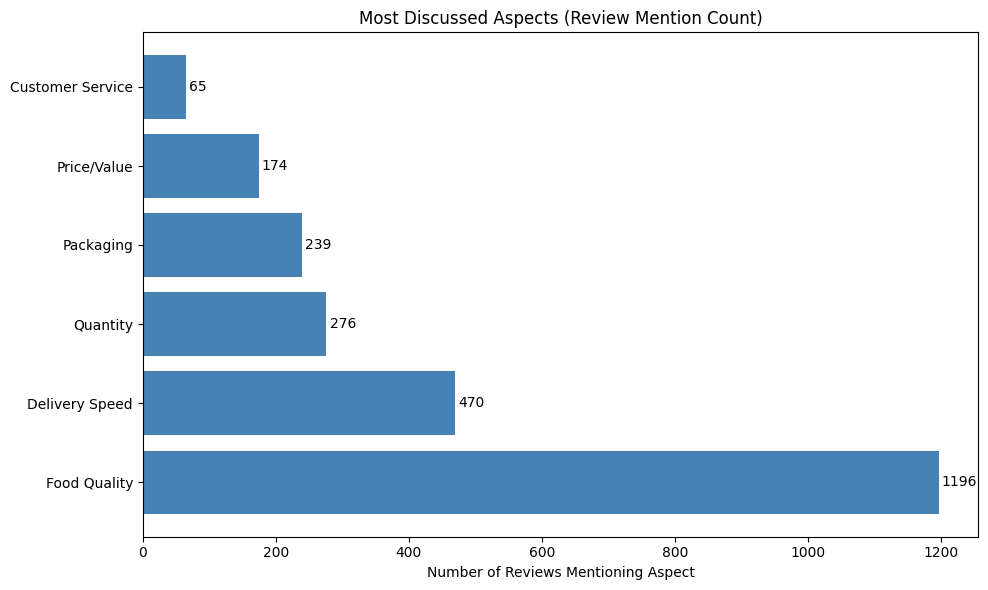

In [41]:
import matplotlib.pyplot as plt

# Count mentions per aspect
aspect_counts = {}
for aspect in aspects.keys():
    aspect_counts[aspect] = df['aspects'].apply(
        lambda x: aspect in x).sum()

# Sort by count
aspect_counts = dict(sorted(aspect_counts.items(),
                            key=lambda x: x[1],
                            reverse=True))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(list(aspect_counts.keys()),
         list(aspect_counts.values()),
         color='steelblue')

# Add count labels
for i, (aspect, count) in enumerate(aspect_counts.items()):
    plt.text(count + 5, i, str(count), va='center')

plt.title('Most Discussed Aspects (Review Mention Count)')
plt.xlabel('Number of Reviews Mentioning Aspect')
plt.tight_layout()
plt.show()

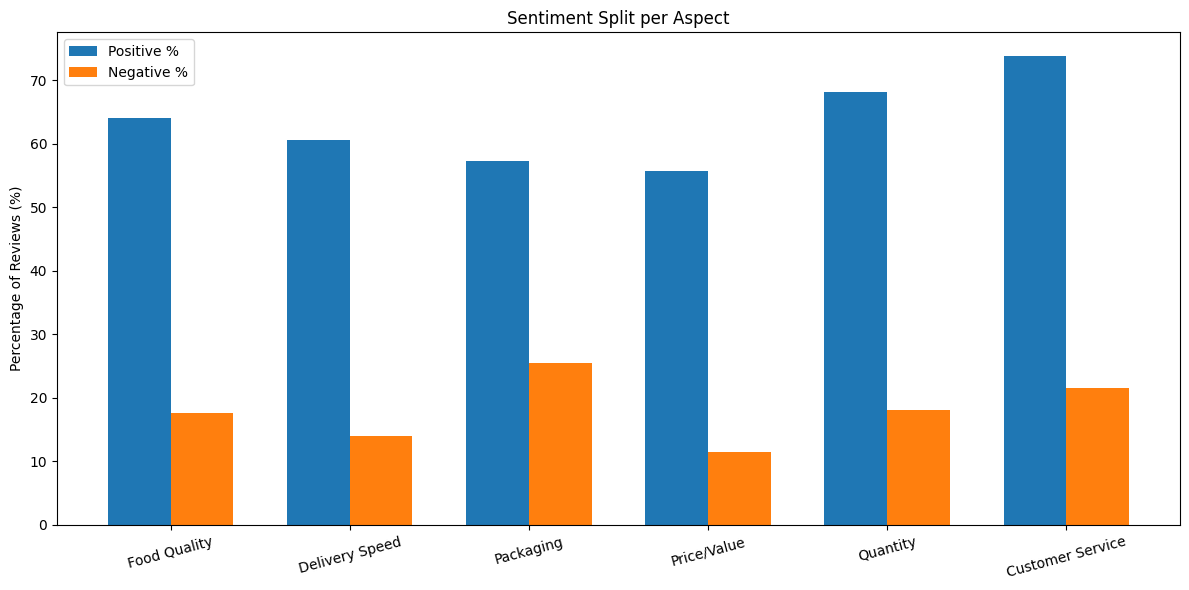

In [42]:
import numpy as np

# Store sentiment percentages
positive_percent = []
negative_percent = []

aspect_names = list(aspects.keys())

for aspect in aspect_names:

    # reviews containing this aspect
    aspect_df = df[df['aspects'].apply(lambda x: aspect in x)]

    total = len(aspect_df)

    # sentiment counts
    positive = (aspect_df['sentiment_label'] == 'Positive').sum()
    negative = (aspect_df['sentiment_label'] == 'Negative').sum()

    # percentages
    if total > 0: # Avoid division by zero for aspects with no reviews
        positive_percent.append((positive / total) * 100)
        negative_percent.append((negative / total) * 100)
    else:
        positive_percent.append(0)
        negative_percent.append(0)

# Bar positions
x = np.arange(len(aspect_names))
width = 0.35

# Plot
plt.figure(figsize=(12,6))

plt.bar(x - width/2,
        positive_percent,
        width,
        label='Positive %')

plt.bar(x + width/2,
        negative_percent,
        width,
        label='Negative %')

# Labels
plt.xticks(x, aspect_names, rotation=15)
plt.ylabel('Percentage of Reviews (%)')
plt.title('Sentiment Split per Aspect')

plt.legend()

plt.tight_layout()
plt.show()

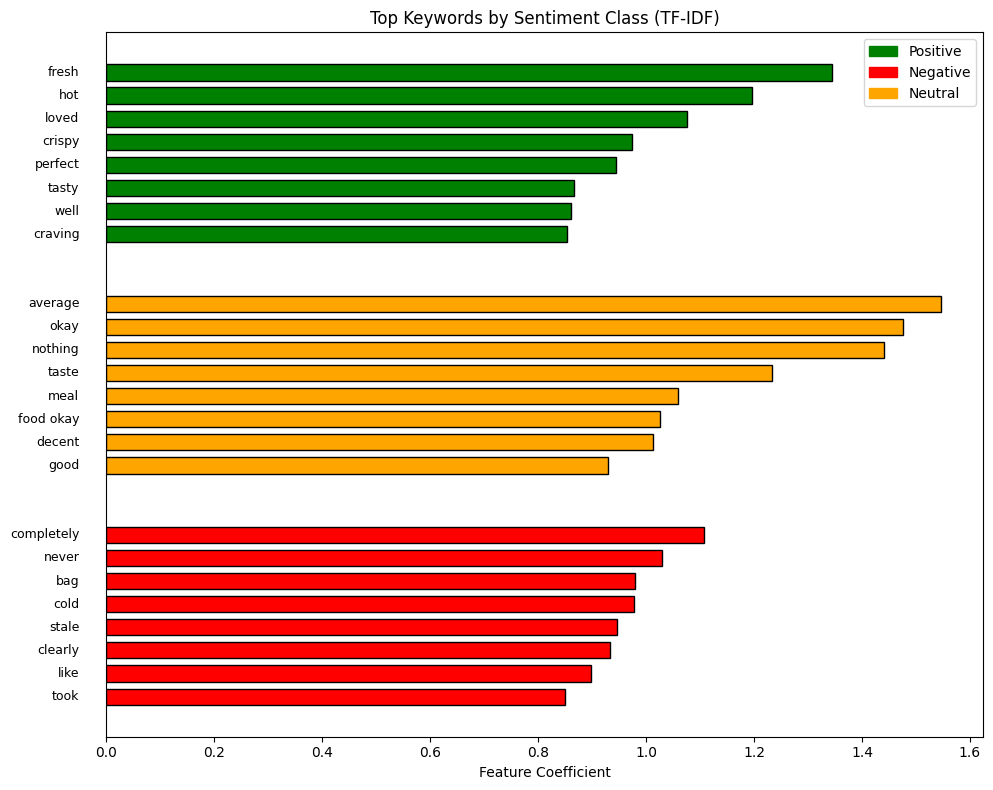

In [43]:
feature_names = np.array(tfidf.get_feature_names_out())

classes = lr.classes_  # ['Negative', 'Neutral', 'Positive']
colors = ['red', 'orange', 'green']
top_n = 8

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = 0
labels = []
positions = []

for idx, (class_name, color) in enumerate(zip(classes, colors)):
    coef = lr.coef_[idx]
    top_idx = np.argsort(coef)[-top_n:]
    top_words = feature_names[top_idx]
    top_vals = coef[top_idx]

    for word, val in zip(top_words, top_vals):
        ax.barh(y_pos, val, color=color, edgecolor='black', height=0.7)
        ax.text(-0.05, y_pos, word, ha='right', va='center', fontsize=9)
        positions.append(y_pos)
        y_pos += 1
    y_pos += 2  # gap between classes

ax.set_title('Top Keywords by Sentiment Class (TF-IDF)')
ax.set_xlabel('Feature Coefficient')
ax.set_yticks([])

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='green', label='Positive'),
          Patch(color='red', label='Negative'),
          Patch(color='orange', label='Neutral')]
ax.legend(handles=legend)

plt.tight_layout()
plt.show()

In [45]:
aspect_summary = pd.DataFrame({
    'Aspect': aspect_names,
    'Mention_Count': [aspect_counts[a] for a in aspect_names],
    'Positive_Pct': [round(p, 1) for p in positive_percent],
    'Negative_Pct': [round(n, 1) for n in negative_percent]
})

print(aspect_summary)
aspect_summary.to_csv('zomato_aspect_summary.csv', index=False)

             Aspect  Mention_Count  Positive_Pct  Negative_Pct
0      Food Quality           1196          64.1          17.6
1    Delivery Speed            470          60.6          14.0
2         Packaging            239          57.3          25.5
3       Price/Value            174          55.7          11.5
4          Quantity            276          68.1          18.1
5  Customer Service             65          73.8          21.5


In [46]:
from google.colab import files
files.download('zomato_aspect_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>